# MCA Timestamp Example

Continuous event logging with microsecond timestamps, plus live histogram.

Uses the `mca_timestamp_1ch` bitfile: IIR highpass -> FIR -> peak detector -> histogram + event logger.

In [12]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from redpitaya_control.redpitaya_dev import redpitaya_dev
from redpitaya_control.event_logger import EventLogger, unpack, load_run, fit_clock, counter_to_unix
from redpitaya_control import compute_coeff

## 1. Connect and configure

In [13]:
RP_HOST = os.environ.get("RP_HOST", "171.64.56.120")
dev = redpitaya_dev(RP_HOST, "config/mca_timestamp_1ch_working.json")
dev.base.load_bitfile()
dev.get_all_registers('iir1')


{'b0': 0.0, 'b1': 0.0, 'a1': 0.0, 'reset': 0.0}

In [14]:
RP_HOST = os.environ.get("RP_HOST", "171.64.56.120")
dev = redpitaya_dev(RP_HOST, "config/mca_timestamp_1ch.json")
dev.base.load_bitfile()

# Signal chain
dev.set_all_registers('iir1', compute_coeff.highpass_1st(1e4, Ts=16e-9), reset=True)
dev.set_register('fir9', 'h0', 0.99)




# Peak detector
dev.set_register("peak_detector", "trig_level", 2, raw=True)
dev.set_register("peak_detector", "fall_level", 1, raw=True)
dev.set_register("peak_detector", "base_return", 0, raw=True)
dev.set_register("peak_detector", "dead_time", 1000, raw=True)

# Use 0 for positive-going pulses, 1 for negative-going pulses
dev.set_register("peak_detector", "invert_input", 0, raw=True)



dev.set_register("peak_detector", "n_integration", 1000)

# Histogram
dev.set_register("histogram", "offset", 0)
dev.set_register("histogram", "gain", 0.08)
dev.set_register("histogram", "band_low", 0.01)
dev.set_register("histogram", "band_high", 0.99)
dev.set_register("histogram", "pulse_width", 1024)
dev.set_register("histogram", "clear_bins", 1)
time.sleep(0.01)
dev.set_register("histogram", "clear_bins", 0)
dev.set_register("histogram", "counting_enable", 1)

## 2. Run the event logger

Set `duration=None` to run until Ctrl+C.

In [15]:
log = EventLogger(dev)

MAX_Q15 = 32767 / 32768

log = EventLogger(dev)
log.configure(
    band_low=0.0,
    band_high=MAX_Q15,
    flush_ms=100,
)

print(
    dev.get_register("event_logger", "band_low", raw=True),
    dev.get_register("event_logger", "band_high", raw=True),
)
# Must print: 0 32767

n = log.run(duration=5, output_dir="run1")

for _ in range(20):
    print(
        "x =", dev.get_register("peak_detector", "x_in", raw=True),
        "state =", dev.get_register("peak_detector", "state_out", raw=True),
        "peak =", dev.get_register("peak_detector", "peak_value_out", raw=True),
    )
    time.sleep(0.05)

print("peak:", dev.get_register("peak_detector", "peak_max_out", raw=True))
print("events:", dev.get_register("event_logger", "events_lo", raw=True))
print("drained events:", n)
print("FPGA events:",
      dev.get_register("event_logger", "events_lo", raw=True))


0 32767
Logged 0 events, dropped=0
x = 0 state = 0 peak = 0
x = 0 state = 0 peak = 0
x = 0 state = 0 peak = 0
x = 0 state = 0 peak = 0
x = 0 state = 0 peak = 0
x = 0 state = 0 peak = 0
x = 0 state = 0 peak = 0
x = 0 state = 0 peak = 0
x = 0 state = 0 peak = 0
x = 0 state = 0 peak = 0
x = 0 state = 0 peak = 0
x = 0 state = 0 peak = 0
x = 0 state = 0 peak = 0
x = 0 state = 0 peak = 0
x = 0 state = 0 peak = 0
x = 0 state = 0 peak = 0
x = 0 state = 0 peak = 0
x = 0 state = 0 peak = 0
x = 0 state = 0 peak = 0
x = 0 state = 0 peak = 0
peak: 0
events: 0
drained events: 0
FPGA events: 0


In [16]:
log = EventLogger(dev)
log.configure(flush_ms=100)
log.run(duration=5, output_dir="run1")

Logged 0 events, dropped=0


0

## 3. Load and inspect

In [17]:
raw = load_run("run1/events_*.bin")
ts_us, energy, chb = unpack(raw)
print(f"{len(ts_us)} events, span {(ts_us[-1]-ts_us[0])/1e6:.1f} s" if len(ts_us) > 1 else "no events")

no events


## 4. Clock calibration

In [18]:
a, b, ppm = fit_clock("run1/tiepoints.csv")
print(f"Crystal drift: {ppm:+.1f} ppm")
t_unix = counter_to_unix(ts_us, a, b)

Crystal drift: +106514.3 ppm


## 5. Plots

/var/folders/x5/f57jfqdd0rq40qq6hqqmc8gr0000gn/T/ipykernel_42806/3760535358.py:17: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


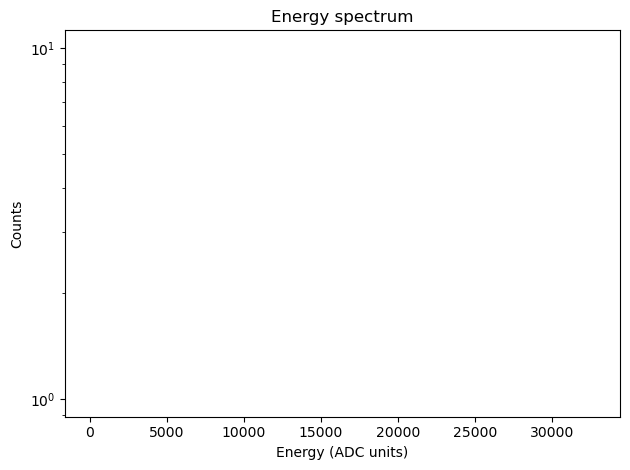

In [19]:

# Energy spectrum
plt.hist(energy, bins=256, range=(0, 2**15), log=True, color='steelblue', edgecolor='none')
plt.xlabel("Energy (ADC units)")
plt.ylabel("Counts")
plt.title("Energy spectrum")

# # Event rate
# if len(t_unix) > 10:
#     t_rel = t_unix - t_unix[0]
#     bins = np.arange(0, t_rel[-1] + 1, 1.0)
#     rate, edges = np.histogram(t_rel, bins=bins)
#     axes[1].step(edges[:-1], rate, where='post', color='darkorange')
#     axes[1].set_xlabel("Time (s)")
#     axes[1].set_ylabel("Events / s")
#     axes[1].set_title("Event rate")

plt.tight_layout()
plt.show()

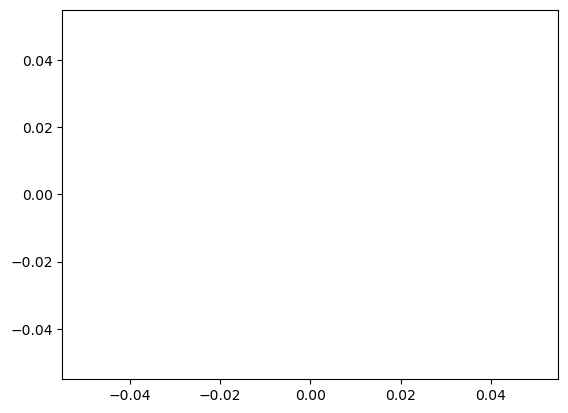

In [20]:
plt.plot(t_unix, energy)